# Linear Regression with Synthetic Data

We generate bivariate data with an underlying linear relationship and Gaussian noise.
We fit a linear regression model using least squares and evaluate the fit quality
with $R^2$ and residual analysis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(12)
n = 50
x = np.linspace(2, 12, n)
y_true = 3.5 * x + 10
y = y_true + np.random.normal(0, 5, n)

coef = np.polyfit(x, y, 1)
y_fit = np.polyval(coef, x)
residuals = y - y_fit

SS_res = np.sum(residuals**2)
SS_tot = np.sum((y - np.mean(y))**2)
R2 = 1 - SS_res / SS_tot

print(f'Fitted equation: y = {coef[0]:.3f}x + {coef[1]:.3f}')
print(f'R2 = {R2:.4f}')

Fitted equation: y = 3.350x + 9.963
R2 = 0.7609


## Scatter plot with regression line

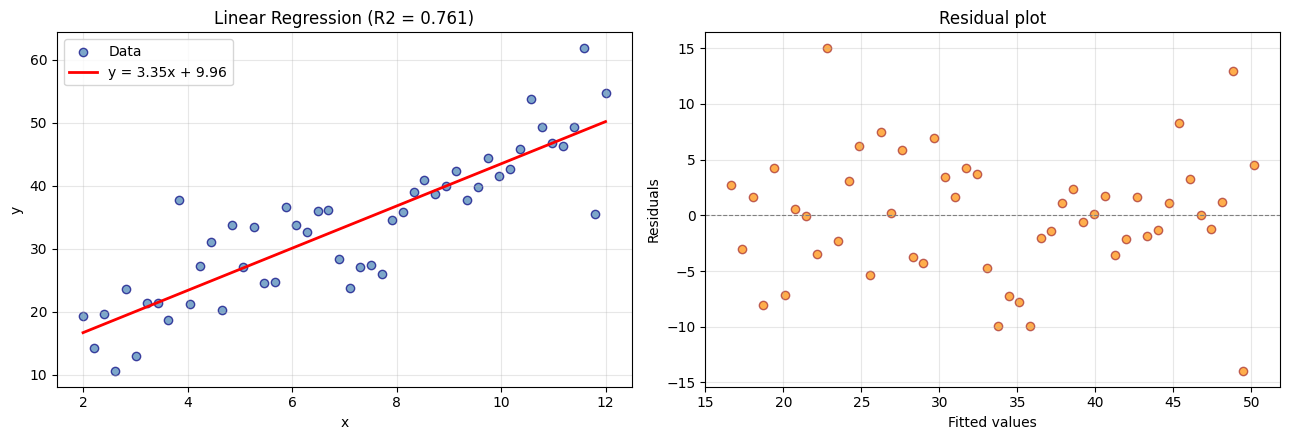

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(x, y, alpha=0.7, color='steelblue', edgecolors='navy', label='Data')
axes[0].plot(x, y_fit, 'r-', linewidth=2, label=f'y = {coef[0]:.2f}x + {coef[1]:.2f}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f'Linear Regression (R2 = {R2:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_fit, residuals, alpha=0.7, color='darkorange', edgecolors='brown')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion

The residual plot allows us to verify regression assumptions: if residuals are
randomly scattered around zero, the linear model is adequate. A pattern in the
residuals would indicate a missing nonlinear term.